In [90]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score , mean_squared_error



In [91]:
dataset = pd.read_csv(r"C:\Users\Muhammad Huzifa\Desktop\Huawei_HCCDA_AI\Cloud-Computing-AI-Course\Cloud-Computing-AI-Course\Week-4\dataset\House_Price\house_price_dataset.csv")

In [92]:
dataset.head()

,Size,Price
0,1360,185186.65
1,1794,250307.74
2,1630,182211.89
3,1595,222267.20
4,2138,263307.52


In [93]:
dataset.tail()

,Size,Price
995,2129,238149.27
996,3051,384466.39
997,2521,320085.05
998,1446,223788.99
999,3121,407136.23


In [94]:
print(f'Number of huses {len(dataset)}')
print(f"Column_Names {dataset.columns.tolist()}")
print(f'Missing_Values: {dataset.isnull().sum()}')

Number of huses 1000
Column_Names ['Size', 'Price']
Missing_Values: Size     0
Price    0
dtype: int64


In [95]:
X = dataset[["Size"]].to_numpy()
y = dataset["Price"].to_numpy()

print(f"Size {X[:5]}")
print(f"Price{y[:5]}")

Size [[1360]
 [1794]
 [1630]
 [1595]
 [2138]]
Price[185186.65 250307.74 182211.89 222267.2  263307.52]


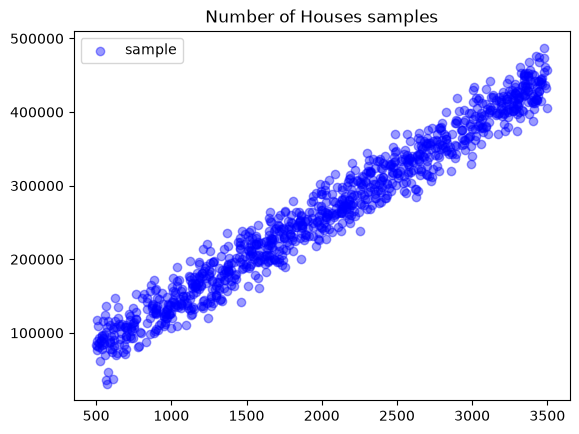

In [96]:
plt.scatter(X ,y, label= "sample" , c = 'b' , alpha = 0.4)
plt.title("Number of Houses samples")
plt.legend()
plt.show() 

In [97]:
X_train , X_test , y_train , y_test = train_test_split(X, y ,test_size = 0.2 , random_state = 42 )
X_train[0] , y_test[0]
len(X_train) , len(X_test)

(800, 200)

In [98]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"{len(X_train_scaled)} {len( X_test_scaled)}")
X_train_scaled[0] , X_test_scaled[0]

800 200


(array([-0.51963998]), array([0.04666003]))

In [101]:
scaler.mean_[0] , scaler.scale_[0]

(2027.95625, 858.2023388082425)

In [89]:
model = LinearRegression()

model.fit(X_train_scaled , y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[103633.77]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.645e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[28.28]


In [25]:
print(f"Weights{model.coef_}")
print(f"learn_intercept{model.intercept_}")

Weights[103633.77268365]
learn_intercept264469.4033375


In [27]:
y_pred = model.predict(X_test_scaled)
print(f"Actual_Values :{y_test[:5]}")
print(f"Predictted: {y_pred[:5]}")


Actual_Values :[289101.97 151447.18 187699.76 226308.18  84684.99]
Predictted: [269304.95865731 176201.46181757 202526.4453598  247085.70649322
  85996.12830357]


In [33]:
mse = mean_squared_error(y_test , y_pred)
mse

402402936.7559436

In [36]:
r2 = r2_score(y_test , y_pred)
r2

0.9676291809811168

In [45]:
costum_size = np.array([1555])


In [ ]:
costum_size_scaled = scaler.transform([costum_size])

In [48]:
New_size = model.predict(costum_size_scaled)
New_size

array([207356.71756939])

In [ ]:
line_size  = np.linspace(X.min() , X.max() , 100).reshape(-1,1)
print(line_size.shape)
line_scale = scaler.transform(line_size)
line_prices = model.predict(line_scale)
plt.scatter(X[:,0] , y , alpha = 0.5 , label = 'actual_line')
plt.plot(line_size , line_prices , c = 'r' , label = 'Predicted_House')
plt.xlabel("Size of house")
plt.ylabel("Price_of HOuse")
plt.legend()

(100,)


In [80]:
import joblib

joblib.dump(
    model,
    "house_price_model.pkl"
)

joblib.dump(
    scaler,
    "house_price_scaler.pkl"
)

print("Model and scaler saved")

Model and scaler saved


In [2]:
import joblib

In [5]:
model = joblib.load(r'C:\Users\Muhammad Huzifa\Desktop\Huawei_HCCDA_AI\Cloud-Computing-AI-Course\Cloud-Computing-AI-Course\Week-5\code\House_Size_Prediction_APP\house_price_model.pkl')

print(model)

LinearRegression()


c:\Users\Muhammad Huzifa\anaconda3\envs\ai_learning\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.7.2 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
